## Opdracht: Ontwerp je Eigen Features & Bouw een Simpele Decision Tree

Je gaat zelf ontdekken hoe je informatie uit afbeeldingen kunt halen door:
- **je mag geen externa libraries gebruiken (behalve numpy)**
- Zelf features te bedenken (kenmerken)
- Die features meetbaar te maken met Python
- Een héél simpele decision tree te bouwen die op basis van jouw features probeert een getal te herkennen
- Te onderzoeken waarom bepaalde features wel of niet goed werken

Je hoeft hiervoor nog niets te weten over machine learning of accuracy.
Deze opdracht gaat om begrijpen, onderzoeken, uitleggen, en experimenteren.

In [59]:
# MNIST laden in Jupyter
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()


### Deel 1 Maak losse methodes per feature

Een feature is één getal dat iets zegt over de afbeelding.
Voorbeelden (je mag kiezen of totaal iets anders verzinnen):

- Hoeveel donkere pixels zitten er in de afbeelding?
- Is de afbeelding links donkerder dan rechts?
- Hoe hoog en hoe breed is de “vorm”?
- Hoe symmetrisch is het cijfer?
- iets met stdev?
- Hoeveel aparte stukjes donkere pixels bevat het?

Kies 5 of meer features die volgens jou iets kunnen zeggen over het cijfer.

1) Welke features heb je gekozen en waarom?
  - Percentage donkere pixels: geeft een idee hoeveel van de afbeelding bestaat uit cijfer. Hanig om onderscheid te makenn tussen cijfers die een groot oppervlak versus een klein oppervlak in nemen.
  - Top bottom ratio: geeft een indicatie waar het cijfer zich bevindt verticaal gezien. Bevind het grootste deel van het cijfer zich boven of onder, kan hiermee worden bepaald.
  - Left right ratio: Het zelfde idee als de top bottom ratio, maar dan horizontaal gezien. Bevind het cijfer zich meer aan de linker kant van de image, of aan de rechterkant, is de vraag die hiermee beantwoord kan worden.
  - Height: Geeft aan hoe hoog een cijfer is.
  - Width: Geeft aan hoe breed een cijfer is. Samen met de height geeft dit een goede indicatie van de vorm van het cijfer.
  - Symmetrie percentage: Geeft een indicatie van hoe symmetrisch een cijfer. Sommige cijfers zijn symmetrisch en andere niet. Deze feature is handig om de symmetrische cijfers van de niet-symmetrische cijfers af te splitsen.
  - Standaarddeviatie: Geeft informatie over hoeveel variatie er is in de pixelwaarden.
  - Average: Geeft informatie over hoe licht of donker een image is (het gemiddelde van de pixelwaardes van een image)


2) Leg de werking uit.
- `percentage_dark_pixels(img)`: Telt het aantal donkere pixels (0). Dit word vervolgens gedeeld door het totaal aantal pixels en omgezet naar een percentage.
Een hoog percentage betekent veel zwarte / donkere pixels, oftewel er is veel achtergrond en weinig cijfer. En een laag percentage betekent het tegenovergesteld: weinig zwart / achtergrond en juist veel cijfer oppervlak.
- `get_top_bottom_ratio(img)`: Splitst de image horizontaal door het midden. De som van de pixelwaarden boven en de som van de pixelwaarden onder worden berkend. De`top_sum` wordt gedeeld door de `bottom_sum` en hier wordt een percentage van gemaakt. Een percentage boven de 100% betekent dat de image in de bovenste helft lichter is dan onder. Het cijfer zit dan dus meer aan de bovenkant. Voor een percentage onder de 100% bevind een groter deel van het cijfer zich aan de onderkant.
- `get_left_right_ratio(img)`: werkt exact hetzelfde als `get_top_bottom_ratio(img)`, maar in plaats dat de afbeelding verticaal wordt gesplitst, wordt de afbeelding horizontaal gesplits. Een percentage boven de 100 betekent dat de afbeelding links lichter is dan rechts. Het cijfer bevindt zich meer aan de linkerkant. Voor een percentage onder de 100 procent geld het tegenovergestelde. De afbeelding bevindt zich meer aan de rechterkant.
- `get_height_and_width_of_shape(img)`: Zoekt de minimale rechthoek die geen zwarte pixels bevat. Vervorlgens wordt het verschil tussen de 'hoogste' en de 'laagste' pixel berekend om de hoogte te bepalen. Voor de breedte wordt het verschil tussen de 'meest linkse' (minst brede?) pixel en de 'meest rechtse' (meest brede) pixel berekend.
- `get_symmetry(img)`: Splitst de image verticaal en spiegelt de linker helft. Deze wordt vevrolgen op de rechterhelft gelegd om te kijken hoeveel pixels met elkaar overeenkomen en hoe symmetrisch de afbeelding dus is. Het percentage geeft aan hoeveel pixels met elkaar overeenkomen. Hoe hoger dit percentage dus is, hoe symmetrischer de afbeelding is.
- `get_stdev_and_average(img)`: met NumPy wordt de avg en de stdev berekend. Een hoog gemiddelde, betekent meer lichte pixels, oftewel een groter cijfer oppervlak. Een lage avg betekent exact het tegenovergestelde, het cijfer bestaat uit weinig pixels. Een hoge stdev betekent dat er veel variatie is in pixelwaardes, en een lage stdev betekent dat er weinig variatie is in pixelwaardes.


In [60]:
def get_percentage(num1, num2):
    return float(round((num1 / num2) * 100, 2))

In [61]:
def percentage_dark_pixels(img):
    # Hoog percentage: Veel zwart, veel achtergrond, weinig cijfer opp
    # Laag percentage: Weinig zwart, weinig achtergrond, veel cijfer opp

    total_pixels = img.size
    dark_pixels = np.sum(img == 0)

    return get_percentage(dark_pixels, total_pixels)


def get_top_bottom_ratio(img):
    # Percentage > 100: Boven lichter dan onder (cijfer zit meer boven)
    # Percentage < 100: Onder lichter dan boven (cijfer zit meer onder)

    top = img[: img.shape[0] // 2, :]
    bottom = img[img.shape[0] // 2 :, :]
    top_sum = np.sum(top)
    bottom_sum = np.sum(bottom)

    if bottom_sum == 0:
        return 100.0
    return get_percentage(top_sum, bottom_sum)


def get_left_right_ratio(img):
    # Percentage > 100: links lichter dan rechts (cijfer zit meer links)
    # Percentage < 100: rechts lichter dan links (cijfer zit meer rechts)

    left = img[:, : img.shape[1] // 2]
    right = img[:, img.shape[1] // 2 :]

    left_sum = np.sum(left)
    right_sum = np.sum(right)

    if right_sum == 0:
        return 100.0
    return get_percentage(left_sum, right_sum)


def get_height_and_width_of_shape(img):
    # In pixels

    rows = np.any(img != 0, axis=1)
    cols = np.any(img != 0, axis=0)

    row_indices = np.where(rows)[0]
    col_indices = np.where(cols)[0]

    if len(row_indices) == 0 or len(col_indices) == 0:
        return 0, 0

    height = row_indices[-1] - row_indices[0] + 1
    width = col_indices[-1] - col_indices[0] + 1

    return int(height), int(width)


def get_symmetry(img):
    # Hoog percentage: Cijfer is symetrisch
    # Laag percentage: Cijfer is niet symetrisch

    left = img[: img.shape[0] // 2, :]
    right = img[img.shape[0] // 2 :, :]

    left_flipped = np.fliplr(left)

    matches = np.sum(left_flipped == right)
    total_pixels = left_flipped.size

    return get_percentage(matches, total_pixels)


def get_stdev_and_average(img):
    # Hoog gemiddelde: meer lichte pixels (cijfer is dik, veel cijfer pixels)
    # Laag gemiddelde: minder lichte pixels (cijfer is dun, weinig cijfer pixels)

    # Lage stdev: Weinig variatie in pixelwaarden
    # Hoge stdev: Veel variatie in pixelwaarden

    average = np.average(img)
    stdev = np.std(img)

    return round(float(average), 2), round(float(stdev), 2)



### Deel 2: Combineer je features

Maak een methode die per afbeelding een matrix van deze features aanmaakt. Roep deze functie aan voor een (sub)set aan Mnist afbeeldingen.

Je mag zelf bepalen in welke datastructuur je het resultaat opslaat. Het is in ieder geval belangrijk dat je de afbeelding en de bijbehorende features opslaat.

In [62]:
def extract_features(img):
    return [
        ("Percentage Dark Pixels", percentage_dark_pixels(img)),
        ("Top-Bottom Ratio", get_top_bottom_ratio(img)),
        ("Left-Right Ratio", get_left_right_ratio(img)),
        ("Height and Width of the Shape", get_height_and_width_of_shape(img)),
        ("Symmetry Percentage", get_symmetry(img)),
        ("Standard Deviation and Average Pixel Value", get_stdev_and_average(img)),
    ]


def create_feature_dataset(images, labels, amount=1000):
    dataset = []

    for i in range(amount):
        img = images[i]
        label = labels[i]

        features = extract_features(img)

        data = {
            "image": img,
            "label": label,
            "features": features
        }

        dataset.append(data)

    return dataset


def display_image(img, label):
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.show()


feature_dataset = create_feature_dataset(x_train, y_train, amount=1000)

print(f"Amount of images: {len(feature_dataset)}")


Amount of images: 1000


1) Op hoeveel afbeeldingen heb je extract_features functie toegepast? Waarom heb je voor dit aantal gekozen?

2) Welke datastructuur heb je gebruikt om je nieuwe dataset in op te slaan en waarom?


#### Antwoorden
**Hoeveelheid afbeeldingen:** <br>
Wij hebben ervoor gekozen om een subset van 1000 afbeeldingen uit de MNIST dataset te halen.

Onze redenen hiervoor zijn:
1. Werkzaamheid en snelheid van het programma: <br>
  De trainingset bevat in totaal 60.000 afbeeldingen. Als we een decision tree gaan bouwen voor alle 60.000 afbeeldingen zou dit te veel tijd kosten en te veel geheugen gebruiken. Op een normale computer zal dit nooit passen.
2. Representatieve subset: <br>
  Met een subset van 1000 afbeeldingen kunnen we een representatieve steekproef van de dataset verkrijgen. Dit zijn voldoende afbeeldingen om een klein werkend model mee trainen. Wij verwachten dat de meeste cijfers en patronen herkend kunnen worden met deze subset van data, zonder dat het programma te zwaar wordt.

Met deze subset van 1000 afbeeldingen hebben we een goede balans tussen werkzaamheid, snelheid en representativiteit.



**Datastructuur:** <br>
Wij hebben als datastructuur een list van dictionaries gebruikt. <br>
De dictionary ziet er als volgt uit:
```
{
  "image": img,
  "label": label,
  "features": features
}
```

Hierin is img de originele `ndarray` van de afbeelding, label het cijfer en features de list van features die de functie `extract_features(img)` ophaalt.

Onze redenen hiervoor zijn:
1. Overzichtelijk en compact: <br>
  Voor elke afbeelding hebben we de benodigde gegevens overzichtelijk verzameld. Dit is handig voor het ophalen van de features en het maken van de decision tree. Elke dictionary bevat alles wat we nodig hebben voor 1 afbeelding.
2. Geheugen: <br>
  Deze datastructuur neemt relatief weinig geheugen in gebruik.
3. Loops: <br>
  Een list is gemaakt om door heen te loopen. Dit is precies de actie die we moeten gaan uitvoeren om de decision tree te maken, trainen en voorspellingen te doen. Andere datastructuren als bijvoorbeeld een queue of een stack zijn hier niet voor gemaakt. Hetzelfde geld voor een dictionary. Die is gemaakt om op key te zoeken. Dit passen we toe op de enkele afbeeldingen om gemakkelijk de features op te halen.



### Deel 3: Decision tree maken

We gebruiken **geen scikit-learn** .
Je bouwt een klein boompje met splitsingen.

Je tree werkt zo:

“Als feature X kleiner is dan drempel T → linkerkind
Anders → rechterkind”

In [63]:
def get_feature_values(feature_list):
    dark_pixels = feature_list[0][1]
    tb_ratio = feature_list[1][1]
    lr_ratio = feature_list[2][1]
    height, width = feature_list[3][1]
    symmetry = feature_list[4][1]
    avg, stdev = feature_list[5][1]

    return dark_pixels, tb_ratio, lr_ratio, height, width, symmetry, avg, stdev

In [64]:
def get_thresholds(dataset):
    dark_values = []
    symmetry_values = []
    tb_ratio_values = []
    lr_ratio_values = []
    height_values = []
    width_values = []
    avg_values = []
    stdev_values = []

    for item in dataset:
        dark, tb_ratio, lr_ratio, height, width, symmetry, avg, stdev = get_feature_values(item["features"])

        dark_values.append(dark)
        symmetry_values.append(symmetry)
        tb_ratio_values.append(tb_ratio)
        lr_ratio_values.append(lr_ratio)
        height_values.append(height)
        width_values.append(width)
        avg_values.append(avg)
        stdev_values.append(stdev)

    thresholds = {
        "dark_pixels": np.median(dark_values),
        "symmetry": np.median(symmetry_values),
        "tb_ratio": np.median(tb_ratio_values),
        "lr_ratio": np.median(lr_ratio_values),
        "height": np.median(height_values),
        "width": np.median(width_values),
        "avg": np.median(avg_values),
        "stdev": np.median(stdev_values)
    }

    return thresholds


In [65]:
def decision_tree(feature_list, thresholds):
    dark_pixels, tb_ratio, lr_ratio, height, width, symmetry, avg, stdev = get_feature_values(feature_list)

    # 1,2,3,4,5,6,7,8,9,0
    if symmetry < thresholds["symmetry"]:
      # 2, 3, 4, 5, 6, 9
      if height < thresholds["height"]:
        # 2, 3, 4, 5
        if width < thresholds["width"]:
          # 2, 3
          if lr_ratio < thresholds["lr_ratio"]:
            return 3
          else:
            return 2
        else:
          # 4, 5
          if tb_ratio < thresholds["tb_ratio"]:
            return 5
          else:
            return 4
      else:
        # 6, 9
        if tb_ratio < thresholds["tb_ratio"]:
          return 6
        else:
          return 9

    else:
      # 8, 0, 1, 7
      if dark_pixels < thresholds["dark_pixels"]:
        if avg < thresholds["avg"]:
          return 8
        else:
          return 0
      else:
        if tb_ratio < thresholds["tb_ratio"]:
          return 1
        else:
          return 7


### Deel 4: Testen

Je laat de boom op een aantal nieuwe afbeeldingen een voorspelling doen.

Bijvoorbeeld:

- toon 10 nieuwe cijfers
- laat de boom voorspellen
- vergelijk met het echte label
- bespreek wat opvalt

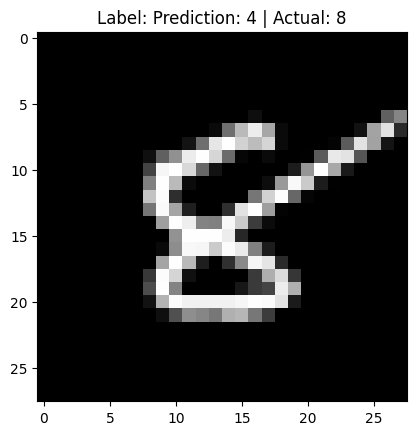

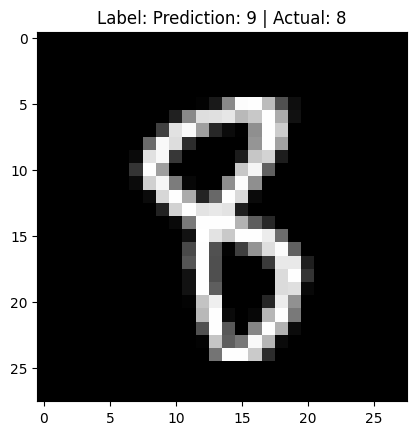

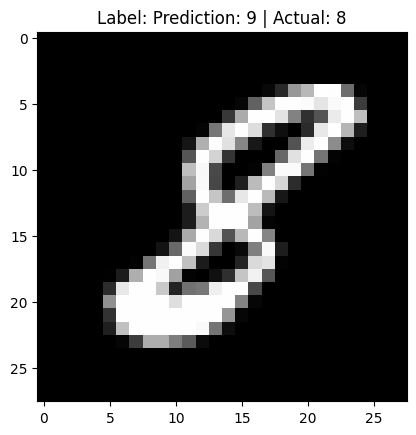

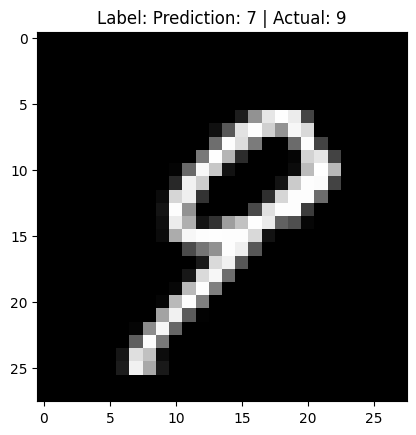

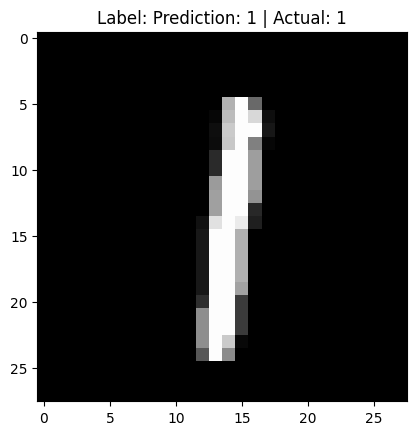

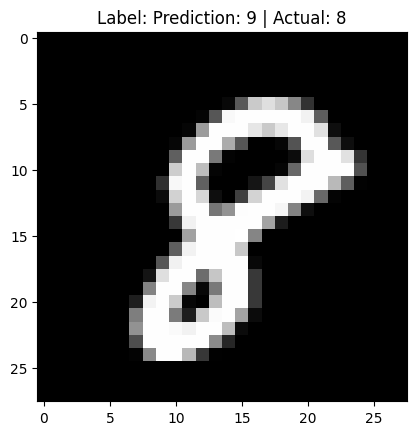

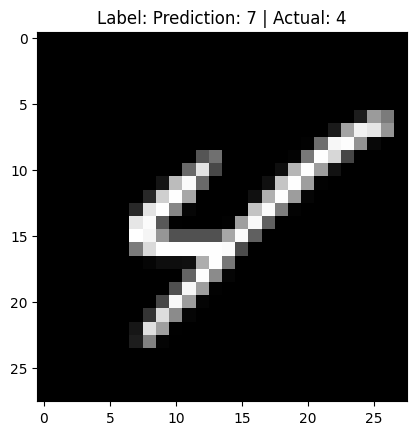

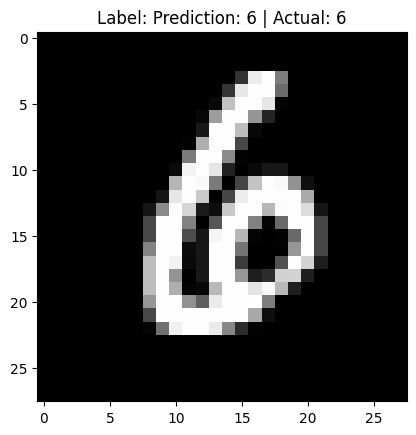

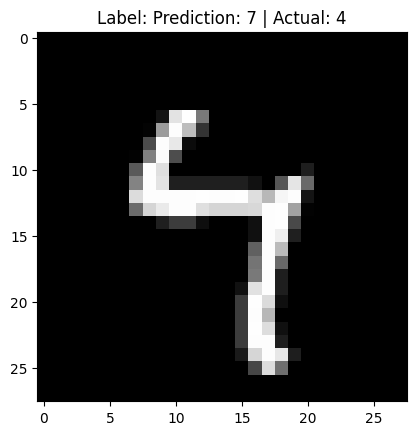

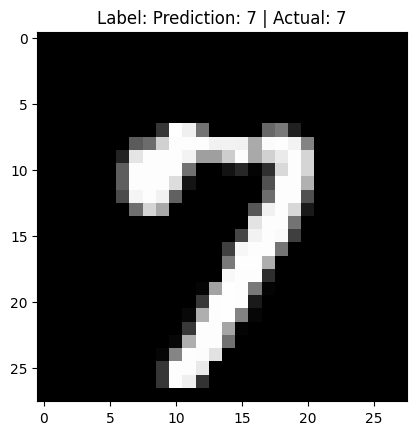

In [66]:
import random

test_subset = random.sample(feature_dataset, 10)

for item in test_subset:
    prediction = decision_tree(item["features"], get_thresholds(feature_dataset))
    actual_label = item["label"]

    display_image(item["image"], f"Prediction: {prediction} | Actual: {actual_label}")


### Deel 5: Runnen als embedded code

Zoals aan het begin van de cursus besproken gaat het project over handgeschreven nummers herekennen op een MysteryDevice met de volgende eigenschappen:

- Input scherm waarmee een nieuwe plaatje als ndarray aangemaakt kan worden door de gebruiker.
- Zeer beperkt RAM (256 KB)
- Beperkte opslag (1 MB voor
programma + model)
- Geen GPU
- Embedded python

Kan je programma er al op runnen?
`

Waarschijnlijk nog niet, want deze code maakt nog gebruik van matplotlib. Voor de rest verwacht ik met de decision tree geen problemente ervaren, want deze bestaat uit slechts een paar zeer simpele if else statements.